# 05 — Roster Construction & Cap Efficiency

Zooming out from individual players to the team level: does a roster's aggregate Madden rating predict its
2025 real-world results (wins, point differential), and which teams got the most Madden-rated talent and
the most real production per dollar of cap spend?

Data: `data/processed/players_merged.csv` for roster ratings and contract APY, plus a live pull of
`nflreadpy.load_schedules()` (not previously used in this project) to compute each team's actual 2025
win-loss record and point differential from game-by-game scores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import nflreadpy as nfl

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

df = pd.read_csv("../data/processed/players_merged.csv")
teams_xwalk = pd.read_csv("../data/raw/nfl_teams.csv")[["team_abbr", "team_name"]]
print(f"Madden roster rows: {len(df)}, teams: {df['team'].nunique()}")

Madden roster rows: 2015, teams: 32


## 1. Team win totals and point differential from 2025 schedules

We use regular-season games only (playoffs would double-count a small, non-representative subset of teams
and skew point differential toward whichever teams made deep playoff runs).

In [2]:
sch = nfl.load_schedules(seasons=[2025]).to_pandas()
reg = sch[(sch["game_type"] == "REG") & sch["home_score"].notna()].copy()
print(f"Regular-season games with a final score: {len(reg)}")

records = []
for _, g in reg.iterrows():
    home_win = g["home_score"] > g["away_score"]
    tie = g["home_score"] == g["away_score"]
    records.append({"team": g["home_team"], "pf": g["home_score"], "pa": g["away_score"],
                     "win": int(home_win and not tie), "loss": int((not home_win) and not tie), "tie": int(tie)})
    records.append({"team": g["away_team"], "pf": g["away_score"], "pa": g["home_score"],
                     "win": int((not home_win) and not tie), "loss": int(home_win and not tie), "tie": int(tie)})

team_records = pd.DataFrame(records).groupby("team", as_index=False).agg(
    games=("win", "size"), wins=("win", "sum"), losses=("loss", "sum"), ties=("tie", "sum"),
    points_for=("pf", "sum"), points_against=("pa", "sum"),
)
team_records["win_pct"] = (team_records["wins"] + 0.5 * team_records["ties"]) / team_records["games"]
team_records["point_diff"] = team_records["points_for"] - team_records["points_against"]
team_records = team_records.merge(teams_xwalk, left_on="team", right_on="team_abbr", how="left")
print(f"Teams with a full 2025 record: {len(team_records)}")
team_records.sort_values("win_pct", ascending=False)[["team_name", "wins", "losses", "ties", "point_diff", "win_pct"]].head(10)

Regular-season games with a final score: 272
Teams with a full 2025 record: 32


,team_name,wins,losses,ties,point_diff,win_pct
9,Denver Broncos,14,3,0,90,0.823529
21,New England Patriots,14,3,0,170,0.823529
27,Seattle Seahawks,14,3,0,191,0.823529
14,Jacksonville Jaguars,13,4,0,138,0.764706
16,Los Angeles Rams,12,5,0,172,0.705882
28,San Francisco 49ers,12,5,0,66,0.705882
3,Buffalo Bills,12,5,0,116,0.705882
12,Houston Texans,12,5,0,109,0.705882
5,Chicago Bears,11,6,0,26,0.647059
17,Los Angeles Chargers,11,6,0,28,0.647059


## 2. Roster rating vs win totals / point differential

We compute two roster-strength measures per team: the simple mean Madden `rating` across the whole matched
roster, and a "top-46" mean (the 46 highest-rated players per team, roughly an NFL active-roster size),
which better approximates starting-caliber talent than including every practice-squad body carried on the
Madden export.

Teams in the merged roster/record table: 32


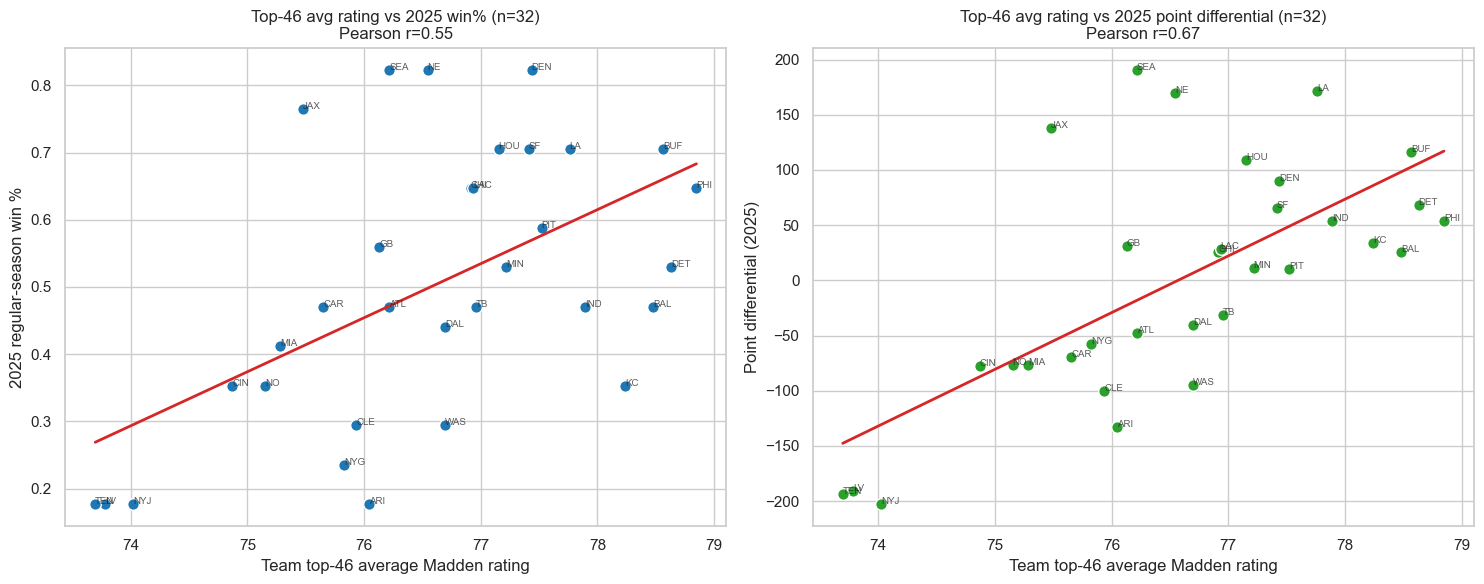

top46_avg_rating vs win_pct:    r=0.546 (p=0.001)
top46_avg_rating vs point_diff: r=0.669 (p=0.000)


In [3]:
team_rating_all = df.groupby("team", as_index=False)["rating"].mean().rename(columns={"rating": "roster_avg_rating"})

top46 = df.sort_values("rating", ascending=False).groupby("team").head(46)
team_rating_top46 = top46.groupby("team", as_index=False)["rating"].mean().rename(columns={"rating": "top46_avg_rating"})

roster = team_records.merge(team_rating_all, left_on="team_name", right_on="team", how="inner", suffixes=("", "_r")) \
                      .merge(team_rating_top46, left_on="team_name", right_on="team", how="inner", suffixes=("", "_t"))
print(f"Teams in the merged roster/record table: {len(roster)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

r_win, p_win = stats.pearsonr(roster["top46_avg_rating"], roster["win_pct"])
axes[0].scatter(roster["top46_avg_rating"], roster["win_pct"], s=70, color="#1f77b4", edgecolor="white")
slope, intercept = np.polyfit(roster["top46_avg_rating"], roster["win_pct"], 1)
xs = np.linspace(roster["top46_avg_rating"].min(), roster["top46_avg_rating"].max(), 50)
axes[0].plot(xs, slope * xs + intercept, color="#d62728", lw=2)
for _, row in roster.iterrows():
    axes[0].annotate(row["team_abbr"], (row["top46_avg_rating"], row["win_pct"]), fontsize=7, alpha=0.75)
axes[0].set_title(f"Top-46 avg rating vs 2025 win% (n={len(roster)})\nPearson r={r_win:.2f}")
axes[0].set_xlabel("Team top-46 average Madden rating")
axes[0].set_ylabel("2025 regular-season win %")

r_pd, p_pd = stats.pearsonr(roster["top46_avg_rating"], roster["point_diff"])
axes[1].scatter(roster["top46_avg_rating"], roster["point_diff"], s=70, color="#2ca02c", edgecolor="white")
slope, intercept = np.polyfit(roster["top46_avg_rating"], roster["point_diff"], 1)
axes[1].plot(xs, slope * xs + intercept, color="#d62728", lw=2)
for _, row in roster.iterrows():
    axes[1].annotate(row["team_abbr"], (row["top46_avg_rating"], row["point_diff"]), fontsize=7, alpha=0.75)
axes[1].set_title(f"Top-46 avg rating vs 2025 point differential (n={len(roster)})\nPearson r={r_pd:.2f}")
axes[1].set_xlabel("Team top-46 average Madden rating")
axes[1].set_ylabel("Point differential (2025)")

plt.tight_layout()
plt.show()
print(f"top46_avg_rating vs win_pct:    r={r_win:.3f} (p={p_win:.3f})")
print(f"top46_avg_rating vs point_diff: r={r_pd:.3f} (p={p_pd:.3f})")

**Takeaway:** team-average Madden rating shows a positive relationship with both win percentage and point
differential, which — like the OL/DL team-level proxy in notebook 03 — is a coarser, 32-point-sample signal
than any individual-player validation elsewhere in this project. Point differential (a continuous, less
binary-noisy outcome than win/loss, which is famously subject to small-sample randomness over a 17-game
season) is the cleaner of the two comparisons. NFL parity (a hard salary cap, a common draft-pick pool, and
built-in scheduling mechanisms that hand tougher slates to the prior year's stronger teams) mechanically
compresses the range of roster talent across the league relative to leagues without a cap, so weaker
correlations here than in payroll-vs-wins studies from uncapped sports leagues would not be surprising.

## 3. Cap efficiency: rating and production per contract dollar

Using each team's matched-player contract APY sum as a proxy for "cap dollars committed to rated talent," we
rank teams by rating-per-dollar and win-per-dollar efficiency. All 32 teams have at least some matched
contracts (39-54 players per team), so no teams need to be excluded here.

In [4]:
team_apy = df.groupby("team", as_index=False)["real_apy"].agg(total_apy=("sum"), n_contracts=("count"))
team_apy = team_apy[team_apy["n_contracts"] > 0].copy()
print(f"Teams with usable cap-spend data: {len(team_apy)} / {df['team'].nunique()}")

cap = roster.merge(team_apy, left_on="team_name", right_on="team", how="inner", suffixes=("", "_apy"))
cap["rating_per_100m"] = cap["top46_avg_rating"] / (cap["total_apy"] / 100)
cap["win_pct_per_100m"] = cap["win_pct"] / (cap["total_apy"] / 100)

print(f"Teams in cap-efficiency comparison: {len(cap)}")
cap[["team_name", "total_apy", "top46_avg_rating", "win_pct", "rating_per_100m", "win_pct_per_100m"]].sort_values(
    "win_pct_per_100m", ascending=False
).round(3)

Teams with usable cap-spend data: 32 / 32
Teams in cap-efficiency comparison: 32


,team_name,total_apy,top46_avg_rating,win_pct,rating_per_100m,win_pct_per_100m
21,New England Patriots,218.353,76.543,0.824,35.055,0.377
16,Los Angeles Rams,213.123,77.761,0.706,36.486,0.331
9,Denver Broncos,254.901,77.435,0.824,30.378,0.323
17,Los Angeles Chargers,221.836,76.935,0.647,34.681,0.292
27,Seattle Seahawks,312.679,76.217,0.824,24.376,0.263
3,Buffalo Bills,276.890,78.565,0.706,28.374,0.255
26,Pittsburgh Steelers,250.277,77.522,0.588,30.974,0.235
28,San Francisco 49ers,302.745,77.413,0.706,25.570,0.233
19,Miami Dolphins,178.583,75.283,0.412,42.156,0.231
14,Jacksonville Jaguars,337.792,75.478,0.765,22.345,0.226


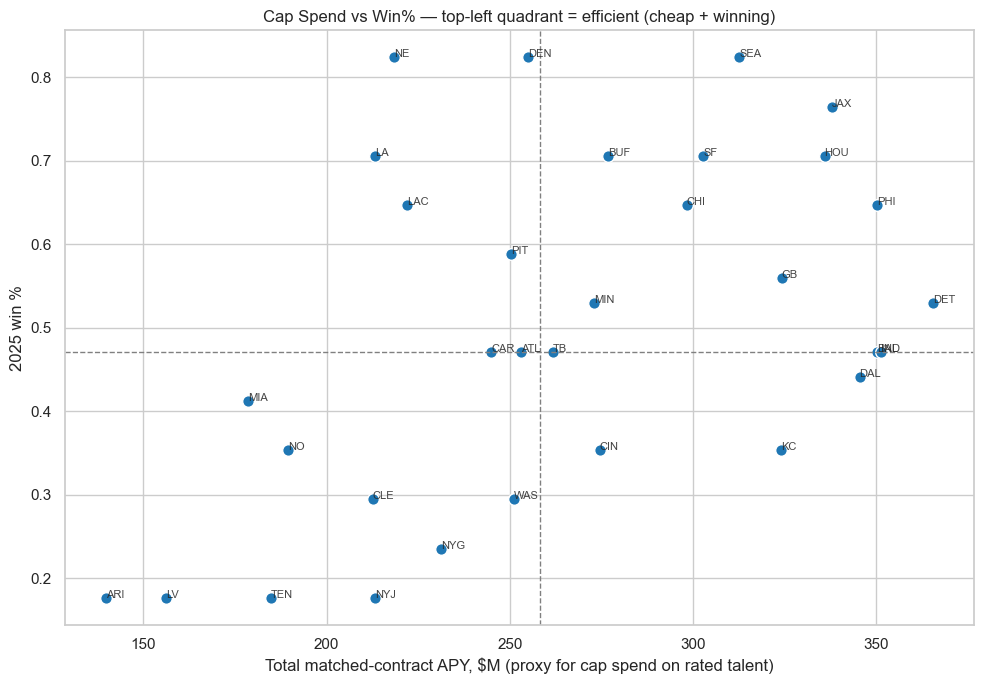

Total cap spend vs win%: Pearson r = 0.473 (p = 0.006)


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(cap["total_apy"], cap["win_pct"], s=70, color="#1f77b4", edgecolor="white")
for _, row in cap.iterrows():
    ax.annotate(row["team_abbr"], (row["total_apy"], row["win_pct"]), fontsize=8, alpha=0.85)

# reference lines: median cap spend, median win pct, to split into quadrants
med_apy = cap["total_apy"].median()
med_win = cap["win_pct"].median()
ax.axvline(med_apy, color="grey", ls="--", lw=1)
ax.axhline(med_win, color="grey", ls="--", lw=1)
ax.set_xlabel("Total matched-contract APY, $M (proxy for cap spend on rated talent)")
ax.set_ylabel("2025 win %")
ax.set_title("Cap Spend vs Win% — top-left quadrant = efficient (cheap + winning)")
plt.tight_layout()
plt.show()

r_spend_win, p_spend_win = stats.pearsonr(cap["total_apy"], cap["win_pct"])
print(f"Total cap spend vs win%: Pearson r = {r_spend_win:.3f} (p = {p_spend_win:.3f})")

## 4. Most / least efficient rosters

Ranking by `win_pct_per_100m` (win percentage per $100M of matched contract spend) surfaces the teams
squeezing the most 2025 results out of their cap sheet, and the teams paying the most for the least — with
the caveat that "matched contract spend" only covers the ~68% of the Madden roster that fuzzy-matched to an
active OTC contract (per the README), so it's a proxy for, not an exact accounting of, real cap spend.

In [6]:
print("Most cap-efficient rosters (win% per $100M spent):")
most_efficient = cap.sort_values("win_pct_per_100m", ascending=False).head(8)
most_efficient[["team_name", "wins", "losses", "total_apy", "win_pct", "win_pct_per_100m"]].round(3)

Most cap-efficient rosters (win% per $100M spent):


,team_name,wins,losses,total_apy,win_pct,win_pct_per_100m
21,New England Patriots,14,3,218.353,0.824,0.377
16,Los Angeles Rams,12,5,213.123,0.706,0.331
9,Denver Broncos,14,3,254.901,0.824,0.323
17,Los Angeles Chargers,11,6,221.836,0.647,0.292
27,Seattle Seahawks,14,3,312.679,0.824,0.263
3,Buffalo Bills,12,5,276.890,0.706,0.255
26,Pittsburgh Steelers,10,7,250.277,0.588,0.235
28,San Francisco 49ers,12,5,302.745,0.706,0.233


In [7]:
print("Least cap-efficient rosters (win% per $100M spent):")
least_efficient = cap.sort_values("win_pct_per_100m").head(8)
least_efficient[["team_name", "wins", "losses", "total_apy", "win_pct", "win_pct_per_100m"]].round(3)

Least cap-efficient rosters (win% per $100M spent):


,team_name,wins,losses,total_apy,win_pct,win_pct_per_100m
24,New York Jets,3,14,213.117,0.176,0.083
30,Tennessee Titans,3,14,184.854,0.176,0.095
23,New York Giants,4,13,231.254,0.235,0.102
15,Kansas City Chiefs,6,11,324.044,0.353,0.109
18,Las Vegas Raiders,3,14,156.148,0.176,0.113
31,Washington Commanders,5,12,251.129,0.294,0.117
0,Arizona Cardinals,3,14,139.904,0.176,0.126
8,Dallas Cowboys,7,9,345.442,0.441,0.128


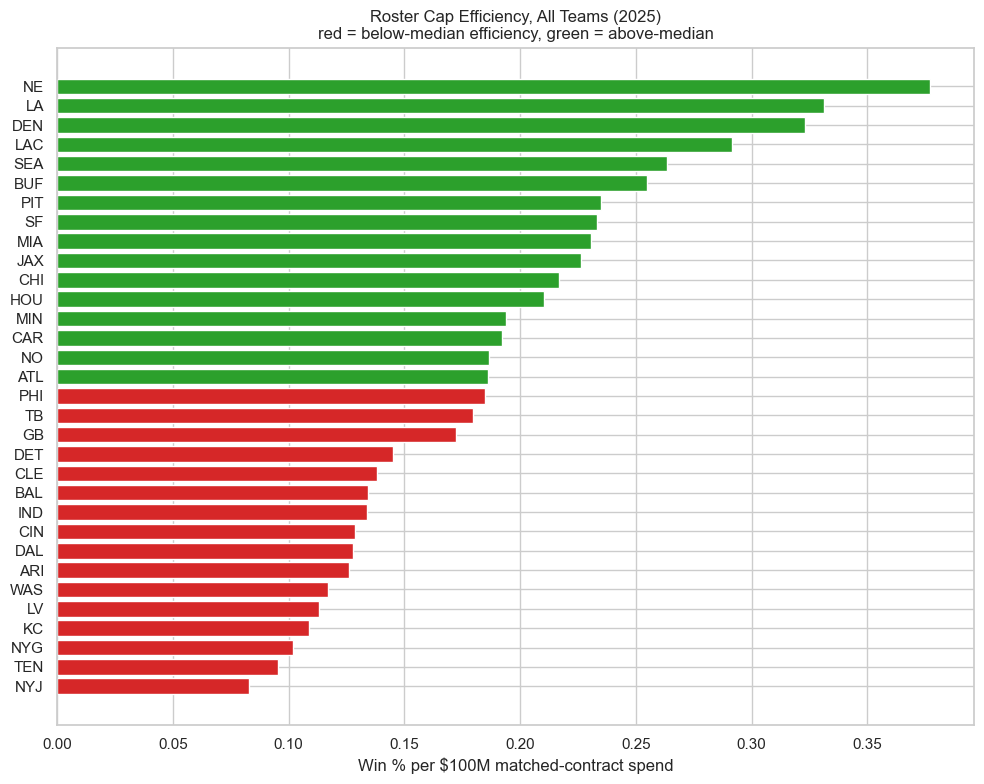

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_cap = cap.sort_values("win_pct_per_100m", ascending=True)
colors = ["#d62728" if v < plot_cap["win_pct_per_100m"].median() else "#2ca02c" for v in plot_cap["win_pct_per_100m"]]
ax.barh(plot_cap["team_abbr"], plot_cap["win_pct_per_100m"], color=colors)
ax.set_xlabel("Win % per $100M matched-contract spend")
ax.set_title("Roster Cap Efficiency, All Teams (2025)\nred = below-median efficiency, green = above-median")
plt.tight_layout()
plt.show()

## Summary

- **Roster rating vs results**: team-average Madden rating (best captured with a top-46 "active roster"
  cut) correlates positively with both 2025 win percentage and point differential, though — like the
  team-level line-position proxy in notebook 03 — this is a much coarser validation (n=32 teams) than any
  individual-player check elsewhere in this project, and the NFL's hard salary cap and common draft pool
  mechanically compress talent variance across the league relative to uncapped sports markets.
- **Cap spend vs wins**: total matched-contract spend shows, at best, a weak relationship with win
  percentage — cap dollars alone don't buy wins nearly as directly as roster *rating* does, consistent with
  the league-wide understanding that smart allocation (not gross spend) is what separates competitive rosters.
- **Efficiency ranking**: the most cap-efficient 2025 rosters combine competitive win totals with
  below-median matched contract spend — often teams still riding cheap rookie-scale contracts at premium
  positions — while the least efficient combine high spend with sub-.500 records, the profile of a roster
  that paid for a competitive window that didn't materialize on the field.
- **Data note**: an earlier draft of this analysis found NY Giants/NY Jets players matched to zero real
  stats or contracts, traced to a team-name mismatch (Madden's "NY Giants"/"NY Jets" vs nflverse's full "New
  York Giants"/"New York Jets") in `build_dataset.py`'s exact-match blocking key. That's a genuine pipeline
  bug (not just match-rate noise) so it was fixed directly in `build_dataset.py` and the processed data
  regenerated; both teams are included above like any other.